In [2]:
import torch
print(torch.__version__)

2.10.0+cpu


In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv('merged_output.csv')

In [6]:
# Convert to datetime
df['CreatedOn'] = pd.to_datetime(df['CreatedOn'])

# Sort by date
df = df.sort_values(['district', 'CreatedOn'])

# Aggregate monthly pest counts
df['year_month'] = df['CreatedOn'].dt.to_period('M')

df_monthly = df.groupby(['district', 'year_month']).agg({
    'pest_count': 'sum',
    'latitude': 'first',
    'longitude': 'first'
}).reset_index()

# Convert period to timestamp
df_monthly['year_month'] = df_monthly['year_month'].dt.to_timestamp()

# Sort again
df_monthly = df_monthly.sort_values(['district', 'year_month'])

df_monthly.head()

,district,year_month,pest_count,latitude,longitude
0,24 PARGANAS (NORTH DISTRICT),2013-04-01,21,22.591967,88.39957
1,24 PARGANAS (NORTH DISTRICT),2013-05-01,24,22.591967,88.39957
2,24 PARGANAS (NORTH DISTRICT),2013-06-01,15,22.591967,88.39957
3,24 PARGANAS (NORTH DISTRICT),2013-07-01,14,22.591967,88.39957
4,24 PARGANAS (NORTH DISTRICT),2013-09-01,22,22.591967,88.39957


In [8]:
from sklearn.neighbors import kneighbors_graph

# Unique districts with coordinates
district_coords = df_monthly[['district', 'latitude', 'longitude']].drop_duplicates().reset_index(drop=True)

# Create adjacency matrix (5 nearest neighbors)
A = kneighbors_graph(
    district_coords[['latitude', 'longitude']],
    n_neighbors=8,
    mode='connectivity',
    include_self=False
)

A = A.toarray()
print(district_coords)
print(A)

                         district   latitude  longitude
0    24 PARGANAS (NORTH DISTRICT)  22.591967  88.399570
1    24 PARGANAS (SOUTH DISTRICT)  22.591967  88.399570
2                        ADILABAD  19.675945  78.533990
3                            AGAR  23.712727  76.017693
4                            AGRA  27.175255  78.009816
..                            ...        ...        ...
538                  WEST TRIPURA  23.916667  91.500000
539                         WOKHA  26.097896  94.254845
540                      YADAGIRI  16.768904  77.138038
541                  YAMUNA NAGAR  30.130000  77.280000
542                      YEVATMAL  20.390000  78.130000

[543 rows x 3 columns]
[[0. 1. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]]


In [10]:
# Pivot to time x district matrix
pivot_df = df_monthly.pivot(index='year_month', 
                            columns='district', 
                            values='pest_count')

pivot_df = pivot_df.fillna(0)

# Convert to numpy
X = pivot_df.values   # shape = (time_steps, districts)

# Normalize
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Add feature dimension
X_scaled = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

print(X_scaled.shape)

(57, 543, 1)


In [12]:
def create_sequences(data, seq_length=12):
    X_seq = []
    y_seq = []

    for i in range(len(data) - seq_length):
        X_seq.append(data[i:i+seq_length])
        y_seq.append(data[i+seq_length])

    return np.array(X_seq), np.array(y_seq)

seq_length = 12
X_seq, y_seq = create_sequences(X_scaled, seq_length)

print(X_seq.shape, y_seq.shape)

(45, 12, 543, 1) (45, 543, 1)


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch_geometric.nn import GATConv
from torch_geometric.utils import dense_to_sparse

edge_index, _ = dense_to_sparse(torch.tensor(A, dtype=torch.float))

class STGAT(nn.Module):

    def __init__(self, num_nodes, in_channels=1, gat_hidden=4, temporal_hidden=8):
        super(STGAT, self).__init__()

        self.num_nodes = num_nodes

        # Temporal convolution
        self.temp1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=temporal_hidden,
            kernel_size=(3,1),
            padding=(1,0)
        )

        # Graph attention
        self.gat = GATConv(temporal_hidden, gat_hidden, heads=2)

        # Second temporal convolution
        self.temp2 = nn.Conv2d(
            in_channels=gat_hidden*2,
            out_channels=temporal_hidden,
            kernel_size=(3,1),
            padding=(1,0)
        )

        self.fc = nn.Linear(temporal_hidden,1)

        self.last_attention = None


    def forward(self,x):

        batch_size, seq_len, num_nodes, features = x.shape

        last_input = x[:,-1,:,:]

        # Temporal convolution
        x = x.permute(0,3,1,2)
        x = F.relu(self.temp1(x))

        x = x.permute(0,2,3,1)

        edge_index_batch = []

        for i in range(batch_size):
            offset = i*num_nodes
            edge_index_batch.append(edge_index + offset)

        edge_index_batch = torch.cat(edge_index_batch,dim=1).to(x.device)

        gat_seq = []

        for t in range(seq_len):

            xt = x[:,t,:,:]
            xt = xt.reshape(batch_size*num_nodes,-1)

            gat_out, (edge_idx, attn_weights) = self.gat(
                xt,
                edge_index_batch,
                return_attention_weights=True
            )

            self.last_attention = attn_weights

            gat_out = gat_out.reshape(batch_size,num_nodes,-1)

            gat_seq.append(gat_out)

        x = torch.stack(gat_seq,dim=1)

        x = x.permute(0,3,1,2)

        x = F.relu(self.temp2(x))

        x = x.permute(0,2,3,1)

        out = self.fc(x[:,-1,:,:])

        out = out + last_input

        return out

In [16]:
# Chronological split (80% train, 20% test)

train_size = int(0.8 * len(X_seq))

X_train = X_seq[:train_size]
y_train = y_seq[:train_size]

X_test = X_seq[train_size:]
y_test = y_seq[train_size:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (36, 12, 543, 1)
Test shape: (9, 12, 543, 1)


In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train_tensor = torch.tensor(X_train, dtype=torch.float).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float).to(device)

X_test_tensor = torch.tensor(X_test, dtype=torch.float).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float).to(device)

In [20]:
model = STGAT(num_nodes=X_seq.shape[2]).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=10
)

epochs = 500
train_losses = []

for epoch in range(epochs):

    model.train()
    optimizer.zero_grad()

    output = model(X_train_tensor)

    loss = criterion(output, y_train_tensor)

    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)

    optimizer.step()

    scheduler.step(loss)

    train_losses.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

D:\Anaconda\envs\pyg_env\lib\site-packages\torch\optim\lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  current = float(metrics)


Epoch 0 | Loss: 0.1041
Epoch 10 | Loss: 0.0953
Epoch 20 | Loss: 0.0902
Epoch 30 | Loss: 0.0877
Epoch 40 | Loss: 0.0866
Epoch 50 | Loss: 0.0862
Epoch 60 | Loss: 0.0860
Epoch 70 | Loss: 0.0858
Epoch 80 | Loss: 0.0856
Epoch 90 | Loss: 0.0853
Epoch 100 | Loss: 0.0851
Epoch 110 | Loss: 0.0848
Epoch 120 | Loss: 0.0845
Epoch 130 | Loss: 0.0842
Epoch 140 | Loss: 0.0839
Epoch 150 | Loss: 0.0836
Epoch 160 | Loss: 0.0833
Epoch 170 | Loss: 0.0830
Epoch 180 | Loss: 0.0827
Epoch 190 | Loss: 0.0824
Epoch 200 | Loss: 0.0822
Epoch 210 | Loss: 0.0819
Epoch 220 | Loss: 0.0817
Epoch 230 | Loss: 0.0815
Epoch 240 | Loss: 0.0813
Epoch 250 | Loss: 0.0811
Epoch 260 | Loss: 0.0810
Epoch 270 | Loss: 0.0808
Epoch 280 | Loss: 0.0807
Epoch 290 | Loss: 0.0806
Epoch 300 | Loss: 0.0804
Epoch 310 | Loss: 0.0803
Epoch 320 | Loss: 0.0802
Epoch 330 | Loss: 0.0801
Epoch 340 | Loss: 0.0801
Epoch 350 | Loss: 0.0800
Epoch 360 | Loss: 0.0799
Epoch 370 | Loss: 0.0798
Epoch 380 | Loss: 0.0798
Epoch 390 | Loss: 0.0797
Epoch 400 |

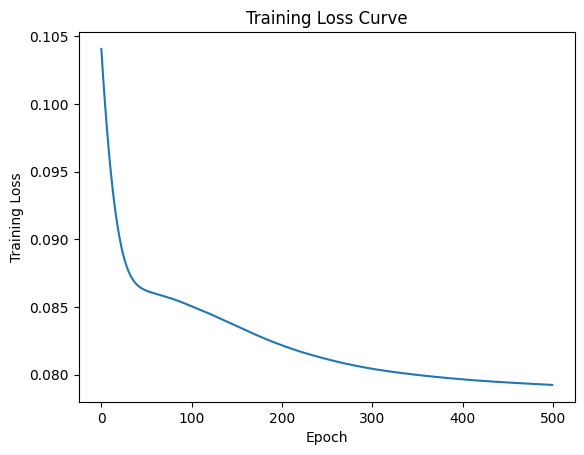

In [22]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.show()

In [40]:
model.eval()

with torch.no_grad():
    test_predictions = model(X_test_tensor)

# Move to CPU
test_predictions = test_predictions.cpu().numpy()
y_test_actual = y_test_tensor.cpu().numpy()

In [42]:
test_predictions = test_predictions.reshape(-1)
y_test_actual = y_test_actual.reshape(-1)


In [44]:
# We must reshape back to original format for inverse scaling

num_districts = pivot_df.shape[1]

pred_reshaped = test_predictions.reshape(-1, num_districts)
actual_reshaped = y_test_actual.reshape(-1, num_districts)

pred_inverse = scaler.inverse_transform(pred_reshaped)
actual_inverse = scaler.inverse_transform(actual_reshaped)

# Flatten again
pred_inverse = pred_inverse.flatten()
actual_inverse = actual_inverse.flatten()

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(actual_inverse, pred_inverse)
rmse = np.sqrt(mean_squared_error(actual_inverse, pred_inverse))
r2 = r2_score(actual_inverse, pred_inverse)

mape = np.mean(np.abs((actual_inverse - pred_inverse) / 
                      (actual_inverse + 1e-8))) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)


MAE : 16.653074264526367
RMSE: 39.197340707689435
R2  : 0.25947290658950806


In [48]:
district_mae = []

for i in range(num_districts):
    mae_d = mean_absolute_error(actual_reshaped[:, i],
                                pred_reshaped[:, i])
    district_mae.append(mae_d)

district_results = pd.DataFrame({
    'district': pivot_df.columns,
    'MAE': district_mae
})

district_results.sort_values('MAE')

,district,MAE
424,RUDRAPRAYAG,0.035169
396,PUNCH,0.038261
9,ALAPPUZHA,0.038401
305,LUDHIANA,0.038407
290,KOZHIKODE,0.038891
...,...,...
265,KATIHAR,0.387433
336,MORADABAD,0.432273
125,DEHRADUN,0.454412
194,HAMIRPUR,0.462793


In [50]:
# reshape back
num_districts = pivot_df.shape[1]

pred_full = pred_inverse.reshape(-1, num_districts)
actual_full = actual_inverse.reshape(-1, num_districts)

# Sum across all districts
total_pred = pred_full.sum(axis=1)
total_actual = actual_full.sum(axis=1)


In [52]:
# Original total pest counts
total_series = pivot_df.sum(axis=1)

# Remove first seq_length months
total_series_seq = total_series[seq_length:]

train_total = total_series_seq[:train_size]
test_total  = total_series_seq[train_size:]

# Dates
dates_seq = pivot_df.index[seq_length:]
train_dates = dates_seq[:train_size]
test_dates  = dates_seq[train_size:]

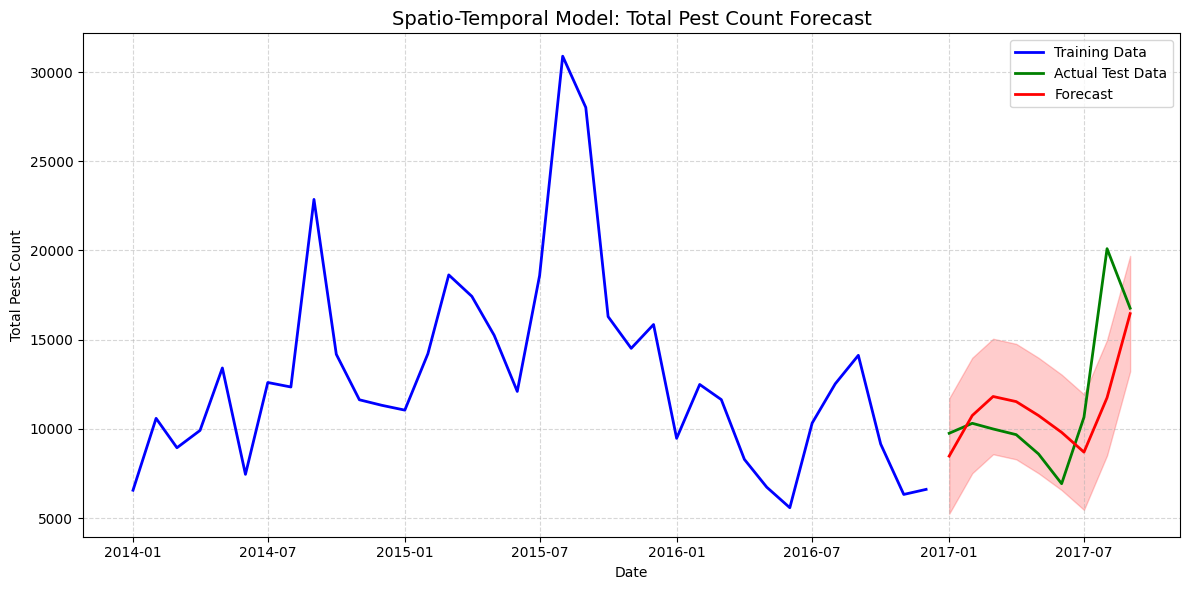

In [54]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,6))

# Training data
plt.plot(train_dates,
         train_total,
         label='Training Data',
         color='blue',
         linewidth=2)

# Actual test
plt.plot(test_dates,
         total_actual,
         label='Actual Test Data',
         color='green',
         linewidth=2)

# Predicted test
plt.plot(test_dates,
         total_pred,
         label='Forecast',
         color='red',
         linewidth=2)

# Confidence band (approximate)
error_std = np.std(total_actual - total_pred)

plt.fill_between(test_dates,
                 total_pred - error_std,
                 total_pred + error_std,
                 color='red',
                 alpha=0.2)

plt.title("Spatio-Temporal Model: Total Pest Count Forecast", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Total Pest Count")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

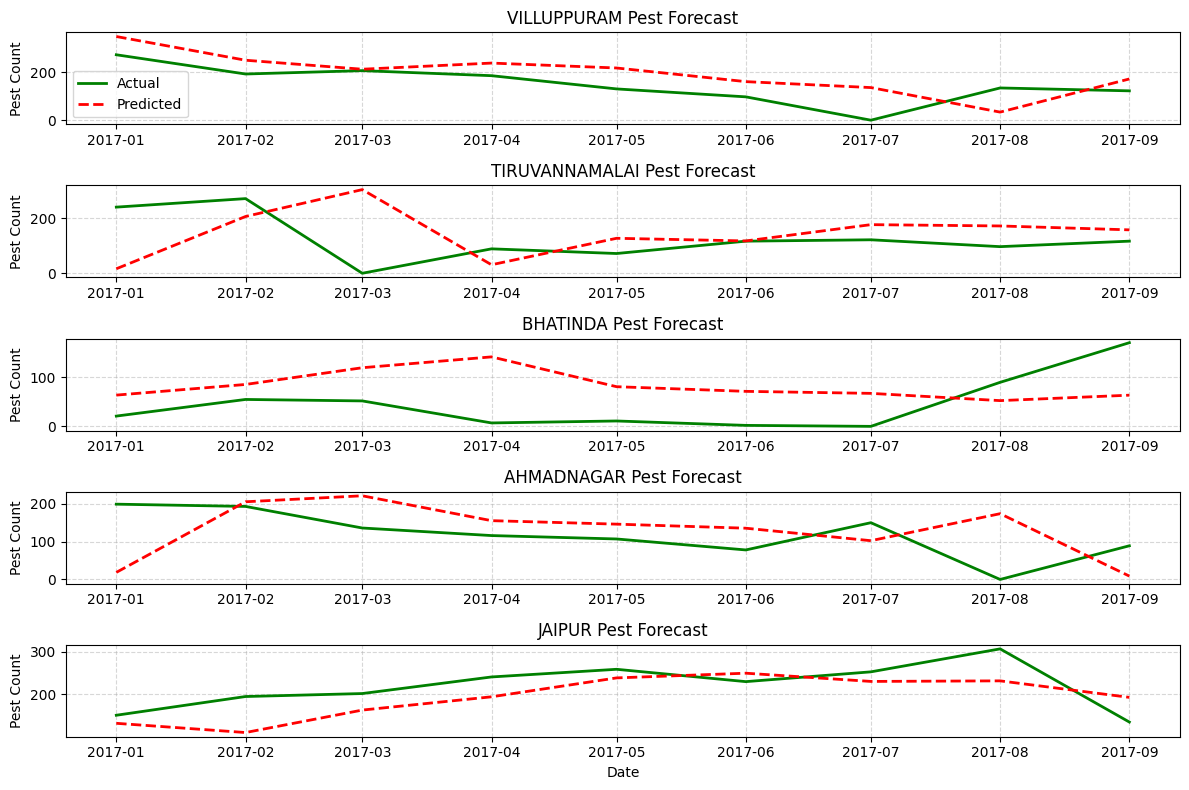

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# Number of districts to plot
num_plot = 5

# Select districts with highest total pest counts
top_district_idx = pivot_df.sum().sort_values(ascending=False).index[:num_plot]

plt.figure(figsize=(12,8))

for i, district in enumerate(top_district_idx):

    d_idx = pivot_df.columns.get_loc(district)

    actual_d = actual_full[:, d_idx]
    pred_d   = pred_full[:, d_idx]

    plt.subplot(num_plot,1,i+1)

    plt.plot(test_dates, actual_d, label='Actual', color='green', linewidth=2)
    plt.plot(test_dates, pred_d, label='Predicted', color='red', linestyle='--', linewidth=2)

    plt.title(f"{district} Pest Forecast")
    plt.ylabel("Pest Count")
    plt.grid(True, linestyle="--", alpha=0.5)

    if i == 0:
        plt.legend()

plt.xlabel("Date")
plt.tight_layout()
plt.show()

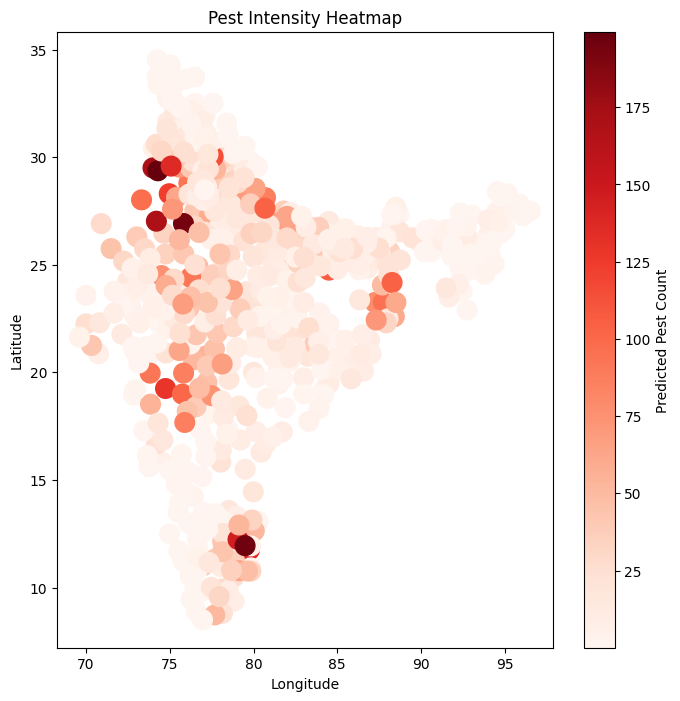

In [58]:
import matplotlib.pyplot as plt

district_pred = pd.DataFrame({
    "district": pivot_df.columns,
    "pest_pred": pred_full.mean(axis=0)
})

district_coords = df_monthly[['district','latitude','longitude']].drop_duplicates()

heatmap_data = district_coords.merge(district_pred,on="district")

plt.figure(figsize=(8,8))

plt.scatter(
    heatmap_data["longitude"],
    heatmap_data["latitude"],
    c=heatmap_data["pest_pred"],
    cmap="Reds",
    s=200
)

plt.colorbar(label="Predicted Pest Count")
plt.title("Pest Intensity Heatmap")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [24]:
model.eval()

with torch.no_grad():
    preds = model(X_test_tensor[:1])

In [26]:
attn = model.last_attention.cpu().numpy()

attn_mean = attn.mean(axis=1)

In [30]:
edges = edge_index.cpu().numpy()

source = edges[0]
target = edges[1]

num_edges = len(source)

attn_trim = attn_mean[:num_edges]

attention_df = pd.DataFrame({
    "source": source,
    "target": target,
    "attention": attn_trim
})

In [32]:
top_edges = attention_df.sort_values("attention",ascending=False).head(20)

print(top_edges)

      source  target  attention
449       56     215   0.502240
2217     277     143   0.500000
399       49     400   0.483638
169       21     277   0.333333
2108     263     312   0.333333
2323     290     312   0.333333
1148     143     277   0.333333
2387     298     275   0.332340
4147     518     275   0.332340
3952     494     103   0.260954
1897     237      56   0.251748
2202     275     298   0.251379
1370     171     295   0.250892
764       95     298   0.250319
1898     237      82   0.250301
852      106     263   0.250000
2498     312     263   0.250000
823      102     501   0.250000
1594     199     263   0.250000
4006     500     501   0.250000


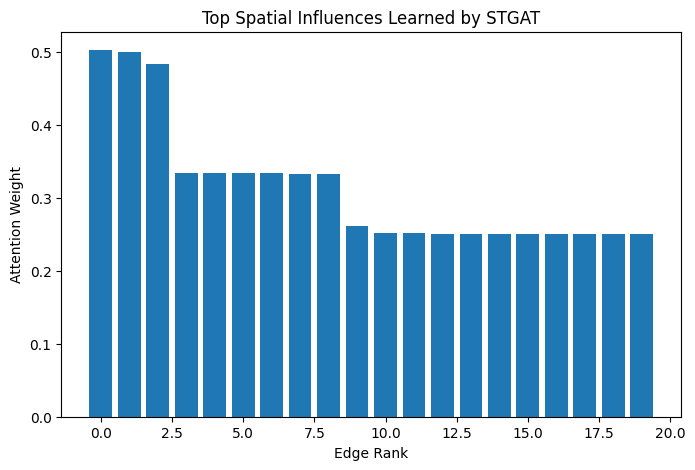

In [34]:
plt.figure(figsize=(8,5))

plt.bar(range(len(top_edges)), top_edges["attention"])

plt.xlabel("Edge Rank")
plt.ylabel("Attention Weight")

plt.title("Top Spatial Influences Learned by STGAT")

plt.show()

In [36]:
influence = attention_df.groupby("source")["attention"].mean()

top_districts = influence.sort_values(ascending=False).head(10)

print(top_districts)

source
49     0.153167
56     0.149949
237    0.148972
240    0.148127
365    0.146836
494    0.146777
189    0.146136
263    0.145379
224    0.143422
407    0.142795
Name: attention, dtype: float32


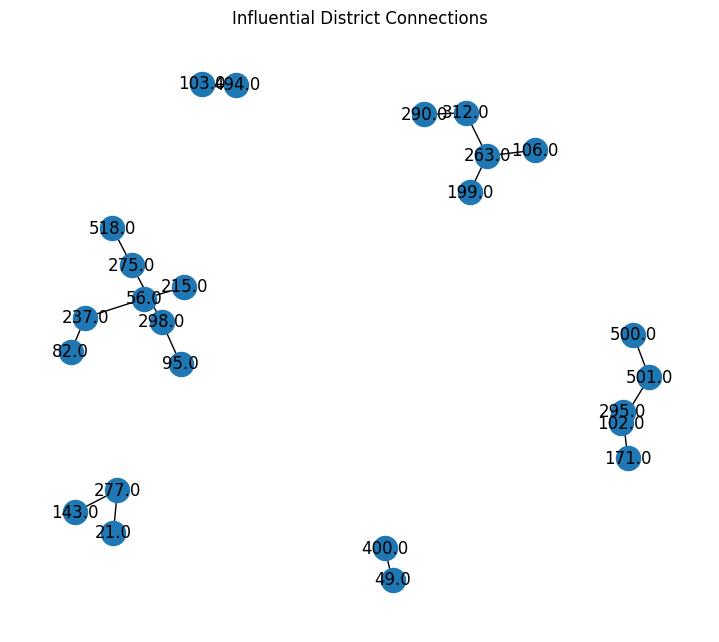

In [38]:
import networkx as nx

G = nx.Graph()

for _,row in top_edges.iterrows():
    G.add_edge(row["source"],row["target"],weight=row["attention"])

plt.figure(figsize=(7,6))

nx.draw(G,with_labels=True)

plt.title("Influential District Connections")

plt.show()